In [121]:
import numpy as np
import pandas as pd

In [122]:
# 4个评价对象，3个指标
X = np.array([[80, 30, 70], [60, 20, 80], [90, 40, 75], [70, 25, 65]])


df = pd.DataFrame(X, columns=["GDP", "污染", "绿化"])

df

,GDP,污染,绿化
0,80,30,70
1,60,20,80
2,90,40,75
3,70,25,65


In [123]:
# 复制，避免修改原数据
X_positive = X.copy()

# 第二列污染指标负向转正向
X_positive[:,1] = X_positive[:,1].max() - X_positive[:,1]

df_positive = pd.DataFrame(X_positive)

df_positive

,0,1,2
0,80,10,70
1,60,20,80
2,90,0,75
3,70,15,65


# 熵权法常用极差标准化：
正向指标：

$$
z_{ij}
=
\frac{x_{ij}-x_{j}^{min}}
{x_{j}^{max}-x_{j}^{min}}
$$


In [124]:
# 标准化矩阵
Z = (X_positive - X_positive.min(axis=0)) / (
    X_positive.max(axis=0) - X_positive.min(axis=0)
)

Z

array([[0.66666667, 0.5       , 0.33333333],
       [0.        , 1.        , 1.        ],
       [1.        , 0.        , 0.66666667],
       [0.33333333, 0.75      , 0.        ]])

In [125]:
# 比例矩阵
P = Z / Z.sum(axis=0)

P

array([[0.33333333, 0.22222222, 0.16666667],
       [0.        , 0.44444444, 0.5       ],
       [0.5       , 0.        , 0.33333333],
       [0.16666667, 0.33333333, 0.        ]])

下一步：计算熵值 $e_j$
公式：
$$
e_j=-k\sum_i p_{ij}\ln(p_{ij})
$$其中：
$$
k=\frac1{\ln n}
$$

熵越大：
$$
e_j \rightarrow 1
$$
说明：
- 指标差异小
- 信息量少

In [126]:
# 评价对象数量
n = P.shape[0]

# 熵值计算系数
k = 1 / np.log(n)

# 避免 log(0),零值保护,当x趋近于0的时候，xlnx = 0
P_safe = np.where(P == 0, 1e-12, P)

# 计算每个指标的熵值
e = -k * np.sum(P_safe * np.log(P_safe), axis=0)

e

# 计算差异系数
d = 1 - e

d

array([0.27042604, 0.23475347, 0.27042604])

# 最后一步：
计算熵权 $w_j$
公式：
$$
w_j=\frac{d_j}{\sum_{j=1}^{m}d_j}
$$

In [127]:
# 计算指标权重
w = d / d.sum()

# 整理
weight_df = pd.DataFrame({"indicator": ["指标1", "指标2", "指标3"], "weight": w})



# 最后一步：计算综合评价得分
熵权法最终目的：
给每个评价对象一个分数。
公式：
$$
S_i=\sum_{j=1}^{m}w_j z_{ij}
$$
也就是：
第 i 个对象的各指标标准化值 × 指标权重，然后求和。

In [128]:
# 计算综合得分
score = Z @ w

score

# 整理成绩排名
final_score = pd.DataFrame({"name": ["A", "B", "C", "D"], "score": score})

# 按得分降序排列
final_score = final_score.sort_values(by="score", ascending=False)

# 添加排名
final_score["rank"] = range(1, len(final_score) + 1)

final_score

,name,score,rank
1,B,0.651336,1
2,C,0.581107,2
0,A,0.500000,3
3,D,0.343225,4


# TOPSIS基本思想
假设有：
- A、B、C、D 四个方案
- 三个评价指标
标准化矩阵：
$$
Z=
\begin{bmatrix}
z_{11}&z_{12}&z_{13}\\
z_{21}&z_{22}&z_{23}\\
...
\end{bmatrix}
$$
先找两个虚拟对象：
正理想解
每个指标都取最好：
$$
Z^+
=
(z_1^+,z_2^+,...,z_m^+)
$$
例如：
指标	最大最好
收入	max
成本	min
效率	max


负理想解
每个指标都取最差：
$$
Z^-
=
(z_1^-,z_2^-,...,z_m^-)
$$
然后计算：
每个对象距离最好多远：
$$
D_i^+
=
\sqrt{
\sum_j
(w_jz_{ij}-w_jz_j^+)^2
}
$$
距离最差多远：
$$
D_i^-
=
\sqrt{
\sum_j
(w_jz_{ij}-w_jz_j^-)^2
}
$$
最后：
$$
C_i=
\frac{D_i^-}{D_i^++D_i^-}
$$
这个 $C_i$ 就是 TOPSIS 得分。
越接近1：
说明越靠近最佳方案。

# 第一步：加权标准化矩阵

In [129]:
# 熵权加权
V = Z * w

V

array([[0.23244293, 0.1513356 , 0.11622147],
       [0.        , 0.30267121, 0.3486644 ],
       [0.3486644 , 0.        , 0.23244293],
       [0.11622147, 0.22700341, 0.        ]])

# 第二步：确定正负理想解

In [130]:
V_positive = V.max(axis=0)

V_negative = V.min(axis=0)

# 第三步：计算距离

In [131]:
D_positive = np.sqrt(((V_positive - V)**2).sum(axis=1))

D_negative = np.sqrt(((V_negative - V) ** 2).sum(axis=1))

# 第四步：计算TOPSIS指数

In [132]:
C = D_negative / (D_positive + D_negative)

topsis_result = pd.DataFrame({"name": ["A", "B", "C", "D"], "score": C})

topsis_result.sort_values(by="score",ascending=False)

,name,score
1,B,0.569749
2,C,0.563790
0,A,0.500000
3,D,0.374572


> 总结：熵权法用于根据指标数据差异程度确定指标权重，得到各指标的重要性；在获得权重后，可以进一步采用加权求和方法计算综合得分，也可以结合TOPSIS方法，通过评价对象与正负理想方案的距离进行排序。实际数学建模中，熵权-TOPSIS更常用于多指标综合评价问题。

# 现在进入模型解释与可靠性分析部分

# 一、先分析熵权结果（权重解释）

In [133]:
weight_df = pd.DataFrame({"indicator": ["指标1", "指标2", "指标3"], "weight": w})

weight_df.sort_values(by="weight", ascending=False)

,indicator,weight
0,指标1,0.348664
2,指标3,0.348664
1,指标2,0.302671


# 二、TOPSIS结果可视化

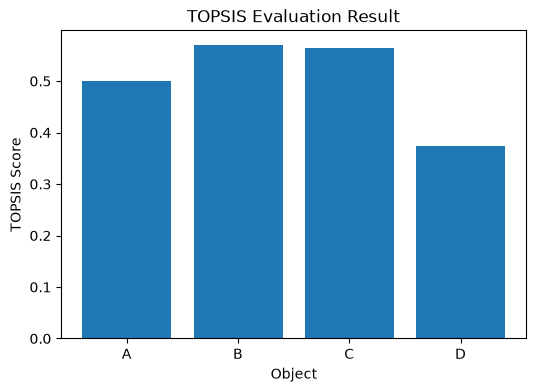

In [134]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6,4))

plt.bar(topsis_result["name"], topsis_result["score"])

plt.xlabel("Object")
plt.ylabel("TOPSIS Score")
plt.title("TOPSIS Evaluation Result")

plt.show()

# 三、敏感性分析（重点)

为什么需要？
因为你的权重来自数据：
如果权重稍微变化：
排名会不会改变？
例如：
现在：
$$
w=(0.347,0.301,0.347)
$$
我们人为改变：
指标1增加10%
$$
w_1'=1.1w_1
$$
然后重新归一化：
$$
w_i=\frac{w_i'}{\sum w_i'}
$$
看排名变化。
如果仍然：
$$
B>C>A>D
$$
说明：
模型排序对权重扰动不敏感，结果具有一定稳定性。

In [135]:
w_test = w.copy()

# 增加第一个指标影响
w_test[0] = w_test[0] * 1.1

# 重新归一化
w_test = w_test / w_test.sum()

w_test

array([0.37060902, 0.29247369, 0.33691729])

  name     score  rank
0    B  0.569749     1
1    C  0.563790     2
2    A  0.500000     3
3    D  0.374572     4


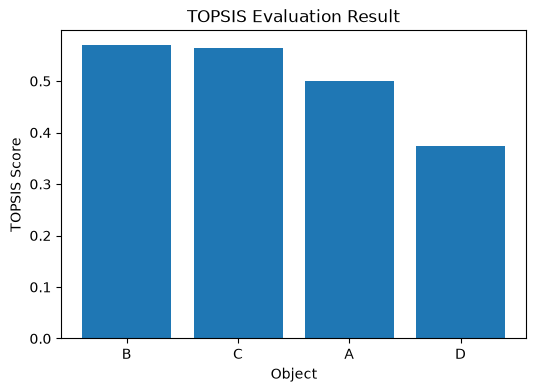

In [147]:
# 重新TOPSIS
V = w * Z

# 确定正负的理想解
V_positive = V.max(axis=0)

V_negative = V.min(axis=0)

# 确定距离
D_positive = np.sqrt(((V_positive - V) ** 2).sum(axis=1))

D_negative = np.sqrt(((V_negative - V) ** 2).sum(axis=1))

# 计算topsis指数
C = D_negative / (D_positive + D_negative)

topsis_result = pd.DataFrame({"name": ["A", "B", "C", "D"], "score": C})

# 排名
topsis_result = topsis_result.sort_values(by="score", ascending=False).reset_index(
    drop=True
)

topsis_result["rank"] = range(1, topsis_result.shape[0]+1)

print(topsis_result)

# 绘制图像
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))

plt.bar(topsis_result["name"], topsis_result["score"])

plt.xlabel("Object")
plt.ylabel("TOPSIS Score")
plt.title("TOPSIS Evaluation Result")

plt.show()

In [148]:
# 保存表格
topsis_result.to_csv("outputs/topsis_result.csv",index=False)